# import libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import RobustScaler, FunctionTransformer
import os

# load data

In [31]:
df = pd.read_csv("../data/sustainable_concrete_dataset.csv", low_memory=True)
df.head(2)

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption
0,312.362036,162.959305,7.851171,1001.810898,771.598763,51,344.476684,307.856482,1628.413117,2256.582173
1,485.214292,187.933066,7.409364,1039.004419,841.629699,71,374.295933,468.240201,2418.001368,2561.190840


# analysis 

In [32]:
df.isnull().sum()

cement                  0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
embodied_CO2            0
energy_consumption      0
resource_consumption    0
dtype: int64

In [33]:
# correlation

In [34]:
corr = df.corr(numeric_only=True)
corr

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption
cement,1.000000,0.029310,0.014518,-0.029424,0.034785,-0.035118,0.229012,0.987426,0.929188,0.591119
water,0.029310,1.000000,0.027262,-0.005791,0.032911,-0.039491,0.053373,0.033279,0.037486,0.170312
superplasticizer,0.014518,0.027262,1.000000,-0.013560,-0.008858,0.052574,-0.038008,0.172333,0.382992,0.057378
coarse_aggregate,-0.029424,-0.005791,-0.013560,1.000000,-0.044812,-0.031235,0.114419,-0.027070,-0.026466,0.527532
fine_aggregate,0.034785,0.032911,-0.008858,-0.044812,1.000000,0.046623,-0.037013,0.034764,0.032547,0.571187
age,-0.035118,-0.039491,0.052574,-0.031235,0.046623,1.000000,-0.900516,-0.026320,-0.013017,-0.013974
compressive_strength,0.229012,0.053373,-0.038008,0.114419,-0.037013,-0.900516,1.000000,0.220010,0.198064,0.182865
embodied_CO2,0.987426,0.033279,0.172333,-0.027070,0.034764,-0.026320,0.220010,1.000000,0.975929,0.594819
energy_consumption,0.929188,0.037486,0.382992,-0.026466,0.032547,-0.013017,0.198064,0.975929,1.000000,0.572728
resource_consumption,0.591119,0.170312,0.057378,0.527532,0.571187,-0.013974,0.182865,0.594819,0.572728,1.000000


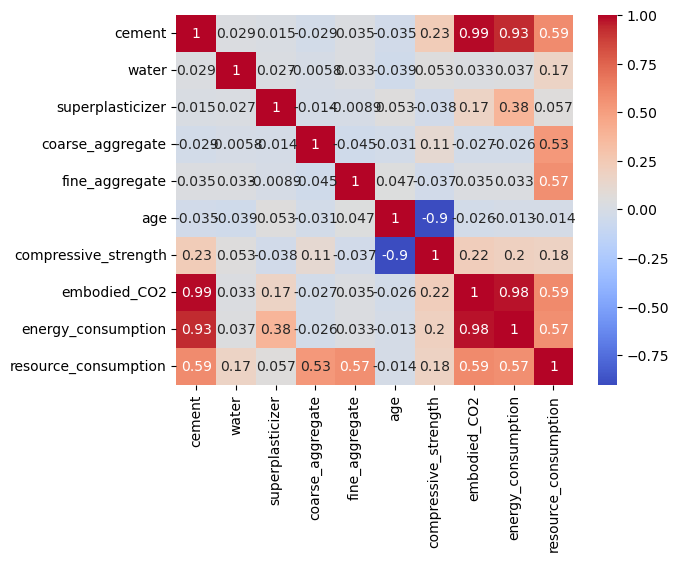

In [35]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm", annot=True)
plt.show()

In [36]:
corr = df.corr(numeric_only=True)
corr[corr.abs() > 0.5]

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption
cement,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.987426,0.929188,0.591119
water,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
superplasticizer,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coarse_aggregate,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.527532
fine_aggregate,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.571187
age,NaN,NaN,NaN,NaN,NaN,1.000000,-0.900516,NaN,NaN,NaN
compressive_strength,NaN,NaN,NaN,NaN,NaN,-0.900516,1.000000,NaN,NaN,NaN
embodied_CO2,0.987426,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.975929,0.594819
energy_consumption,0.929188,NaN,NaN,NaN,NaN,NaN,NaN,0.975929,1.000000,0.572728
resource_consumption,0.591119,NaN,NaN,0.527532,0.571187,NaN,NaN,0.594819,0.572728,1.000000


In [37]:
df.corr(numeric_only=True)["compressive_strength"].sort_values(ascending=False)


compressive_strength    1.000000
cement                  0.229012
embodied_CO2            0.220010
energy_consumption      0.198064
resource_consumption    0.182865
coarse_aggregate        0.114419
water                   0.053373
fine_aggregate         -0.037013
superplasticizer       -0.038008
age                    -0.900516
Name: compressive_strength, dtype: float64

In [38]:
df.corr(numeric_only=True)["energy_consumption"].sort_values(ascending=False)


energy_consumption      1.000000
embodied_CO2            0.975929
cement                  0.929188
resource_consumption    0.572728
superplasticizer        0.382992
compressive_strength    0.198064
water                   0.037486
fine_aggregate          0.032547
age                    -0.013017
coarse_aggregate       -0.026466
Name: energy_consumption, dtype: float64

In [39]:
df.corr(numeric_only=True)["embodied_CO2"].sort_values(ascending=False)


embodied_CO2            1.000000
cement                  0.987426
energy_consumption      0.975929
resource_consumption    0.594819
compressive_strength    0.220010
superplasticizer        0.172333
fine_aggregate          0.034764
water                   0.033279
age                    -0.026320
coarse_aggregate       -0.027070
Name: embodied_CO2, dtype: float64

In [40]:
df.corr(numeric_only=True)["resource_consumption"].sort_values(ascending=False)


resource_consumption    1.000000
embodied_CO2            0.594819
cement                  0.591119
energy_consumption      0.572728
fine_aggregate          0.571187
coarse_aggregate        0.527532
compressive_strength    0.182865
water                   0.170312
superplasticizer        0.057378
age                    -0.013974
Name: resource_consumption, dtype: float64

In [41]:
# scatter dependency

In [42]:
labels = ['compressive_strength', 'resource_consumption', 'embodied_CO2', 'energy_consumption']

features = df.drop( columns=labels)

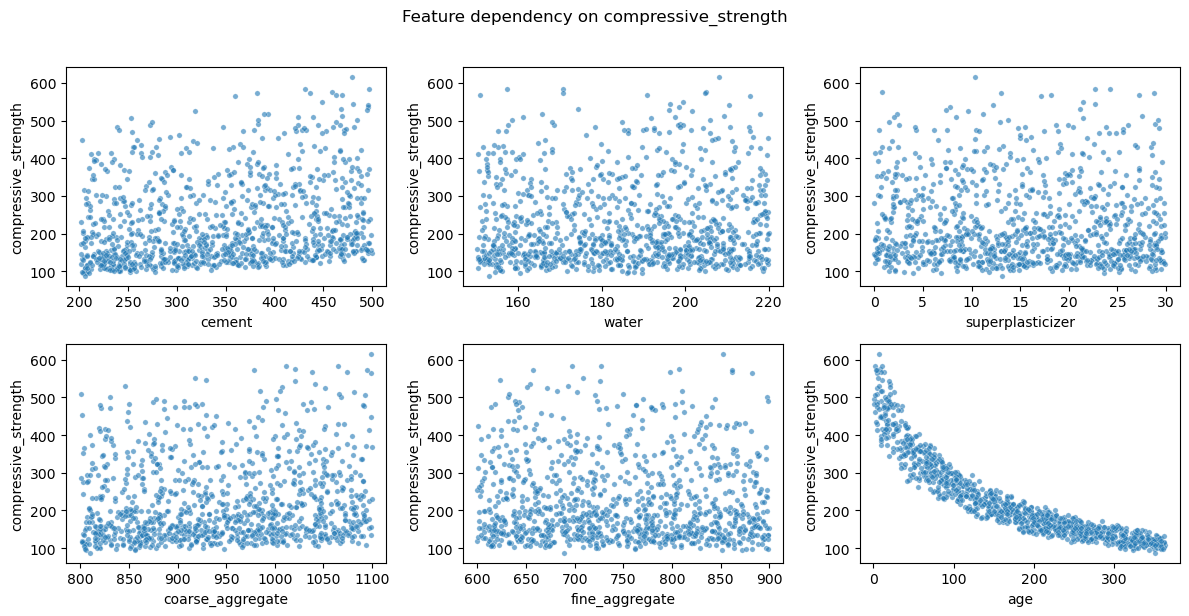

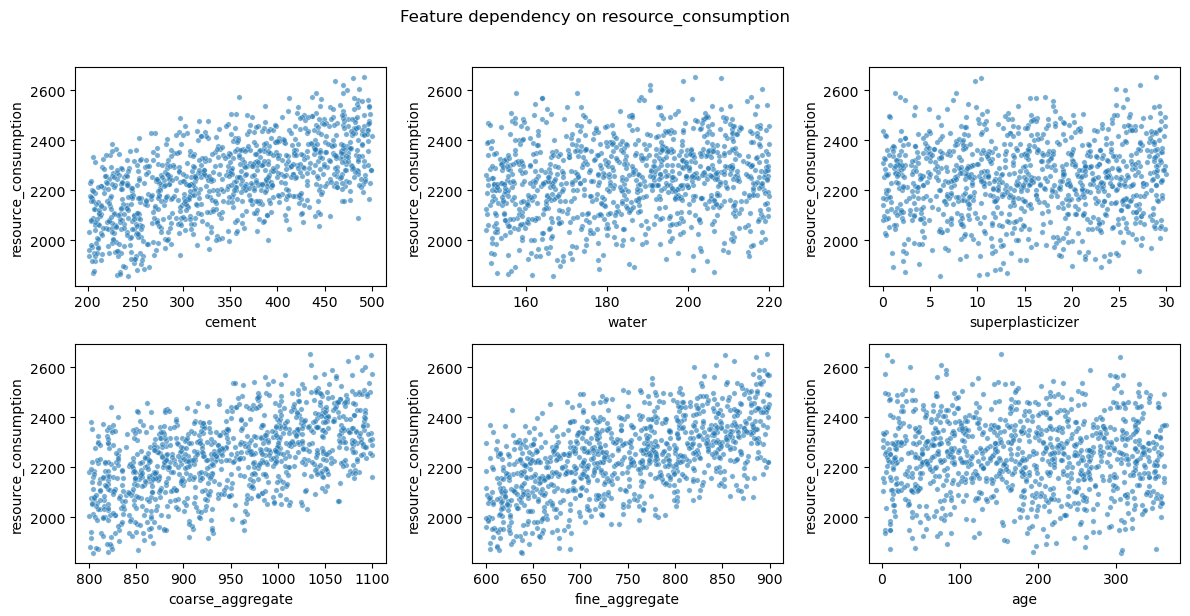

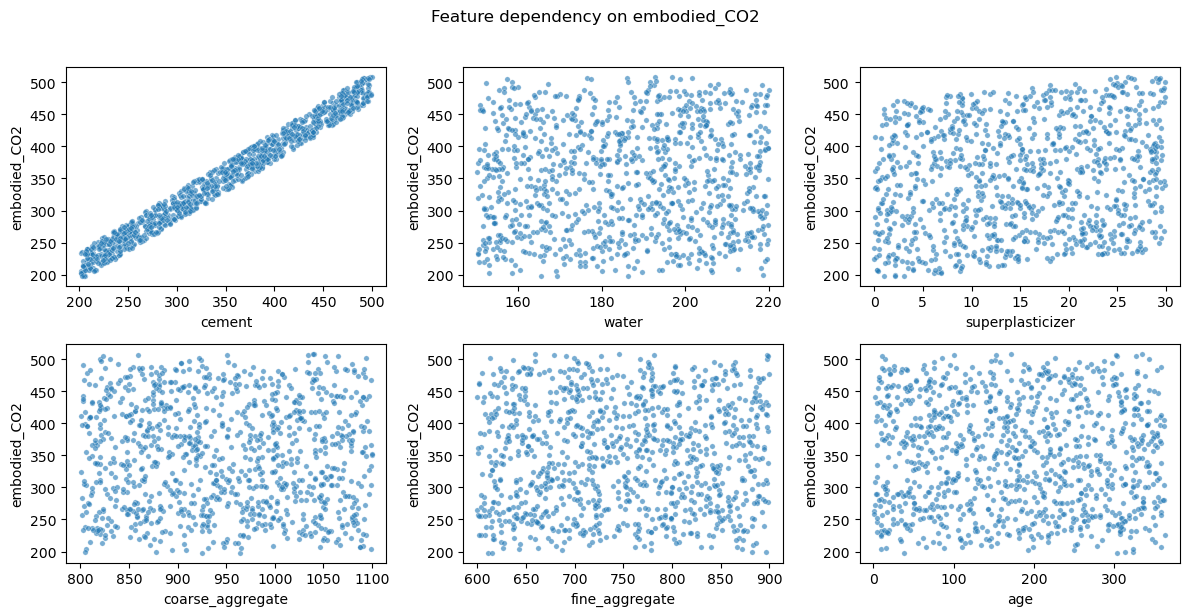

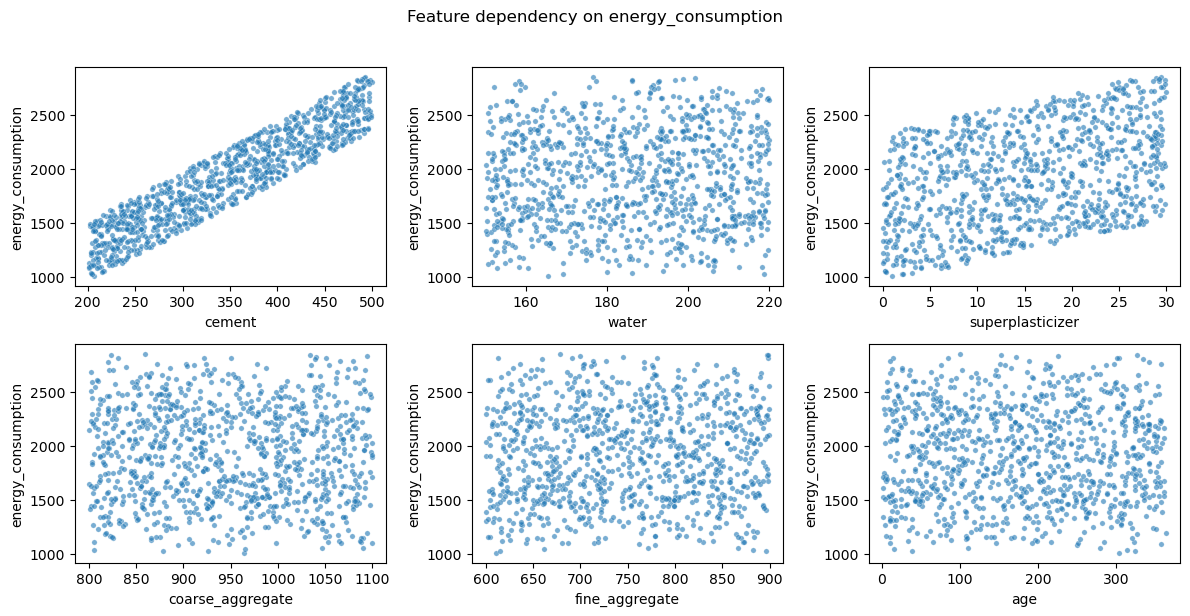

In [43]:
n_cols = 3

for target in labels:
    n_rows = math.ceil(len(features.columns) / n_cols)
    
    plt.figure(figsize=(4 * n_cols, 3 * n_rows))
    
    for i, col in enumerate(features.columns, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(
            data=df,
            x=col,
            y=target,
            s=15,
            alpha=0.6
        )
        plt.xlabel(col)
        plt.ylabel(target)
    
    plt.suptitle(f"Feature dependency on {target}", y=1.02)
    plt.tight_layout()
    plt.show()

# add new columns

In [44]:
eps = 1e-9

df["w_c"] = df["water"] / (df["cement"] + eps)
df["sp_c"] = df["superplasticizer"] / (df["cement"] + eps)

df["agg_total"] = df["coarse_aggregate"] + df["fine_aggregate"]
df["fine_coarse_ratio"] = df["fine_aggregate"] / (df["coarse_aggregate"] + eps)

df["total_mix_mass"] = (
    df["cement"] + df["water"] + df["superplasticizer"] +
    df["coarse_aggregate"] + df["fine_aggregate"]
)

df["paste"] = df["cement"] + df["water"] + df["superplasticizer"]
df["paste_agg_ratio"] = df["paste"] / (df["agg_total"] + eps)

df["log_age"] = np.log1p(df["age"])


In [45]:
ENERGY_MIXING_KWH = 8.5 
ELECTRICITY_EF = 0.45

df['mixing_CO2'] = ENERGY_MIXING_KWH * ELECTRICITY_EF



TRANSPORT_DISTANCE_KM = 50 
TRANSPORT_EF = 0.1

df['total_material_mass'] = (
    df['cement'] +
    df['fine_aggregate'] +
    df['coarse_aggregate'] +
    df['superplasticizer']
)

df['transport_CO2'] = (
    (df['total_material_mass'] / 1000) *
    TRANSPORT_DISTANCE_KM *
    TRANSPORT_EF
)



df['total_CO2'] = (
    df['embodied_CO2'] +
    df['mixing_CO2'] +
    df['transport_CO2']
)


In [46]:
df.head(2)

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption,...,agg_total,fine_coarse_ratio,total_mix_mass,paste,paste_agg_ratio,log_age,mixing_CO2,total_material_mass,transport_CO2,total_CO2
0,312.362036,162.959305,7.851171,1001.810898,771.598763,51,344.476684,307.856482,1628.413117,2256.582173,...,1773.409662,0.770204,2256.582173,483.172511,0.272454,3.951244,3.825,2093.622868,10.468114,322.149596
1,485.214292,187.933066,7.409364,1039.004419,841.629699,71,374.295933,468.240201,2418.001368,2561.190840,...,1880.634118,0.810035,2561.190840,680.556722,0.361876,4.276666,3.825,2373.257774,11.866289,483.931490


In [47]:
# Distribution Analysis

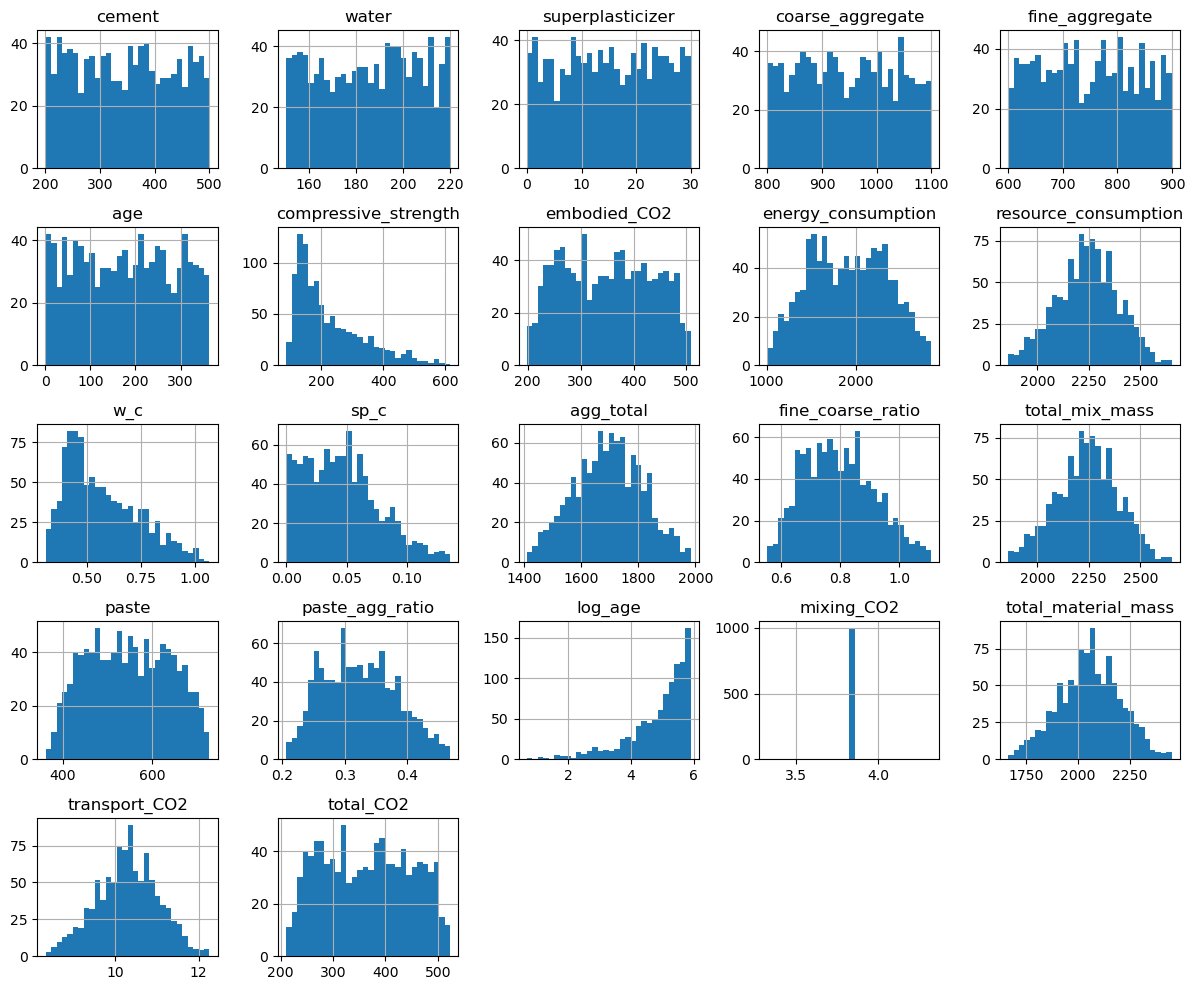

In [48]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()


In [49]:
# Outlier

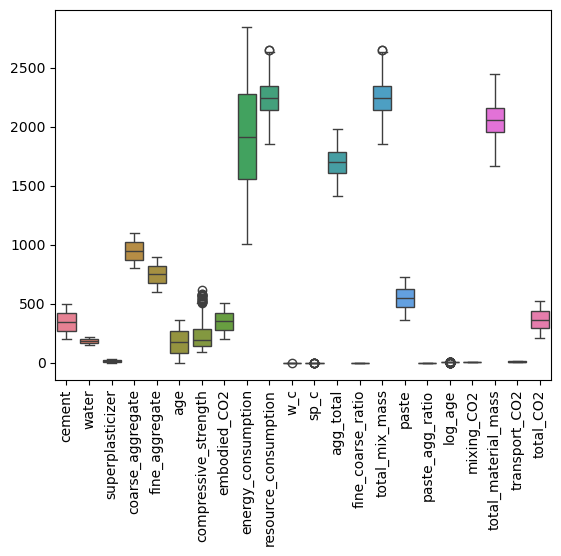

In [50]:
plt.figure()
sns.boxplot(data=df.select_dtypes("number"))
plt.xticks(rotation=90)
plt.show()


In [51]:
# sns.boxplot(x=df["compressive_strength"])


# preprocessing

In [52]:
y = df[labels]
y_log = np.log1p(y)

features = df.drop(columns=labels + ["age"], errors="ignore")

scale_features = features.columns.tolist()

In [53]:
scale_features

['cement',
 'water',
 'superplasticizer',
 'coarse_aggregate',
 'fine_aggregate',
 'w_c',
 'sp_c',
 'agg_total',
 'fine_coarse_ratio',
 'total_mix_mass',
 'paste',
 'paste_agg_ratio',
 'log_age',
 'mixing_CO2',
 'total_material_mass',
 'transport_CO2',
 'total_CO2']

In [54]:
preprocessor = RobustScaler()

X_prepared = preprocessor.fit_transform(features)
X_prepared.shape


(1000, 17)

In [55]:
prepared_cols = preprocessor.get_feature_names_out()
X_prepared_df = pd.DataFrame(X_prepared, columns=prepared_cols, index=features.index)

X_prepared_df.head()

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,w_c,sp_c,agg_total,fine_coarse_ratio,total_mix_mass,paste,paste_agg_ratio,log_age,mixing_CO2,total_material_mass,transport_CO2,total_CO2
0,-0.240520,-0.642293,-0.479974,0.380162,0.156353,-0.046688,-0.436603,0.431143,-0.099284,0.044236,-0.418749,-0.531015,-1.088798,0.0,0.161584,0.161584,-0.305035
1,0.892909,0.044604,-0.509561,0.630300,0.627923,-0.585870,-0.662656,1.045435,0.125640,1.559447,0.871347,0.452243,-0.804719,0.0,1.537457,1.537457,0.825892
2,0.462650,0.681976,0.814944,-0.471736,0.536469,-0.121257,0.472228,0.028846,0.894501,0.564041,0.723211,0.720478,-1.140672,0.0,0.438848,0.438848,0.594159
3,0.200358,0.411041,-0.504403,0.283663,-0.688252,-0.012656,-0.560644,-0.369645,-0.753372,-0.127926,0.268620,0.433175,-1.922919,0.0,-0.197135,-0.197135,0.123596
4,-0.670387,0.554163,-0.459393,0.176472,-0.697647,1.216506,-0.255075,-0.468949,-0.700858,-0.845466,-0.560901,-0.387768,0.326186,0.0,-0.932483,-0.932483,-0.738333


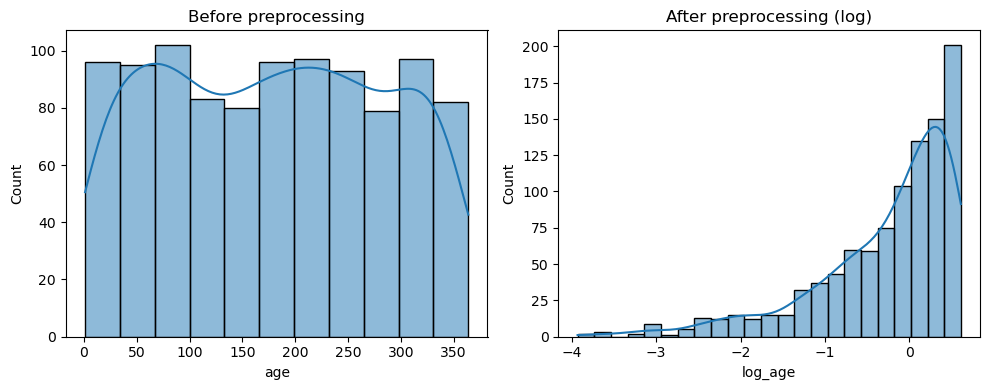

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df[col], kde=True, ax=axes[0])
axes[0].set_title("Before preprocessing")
axes[0].set_xlabel(col)

sns.histplot(X_prepared_df["log_age"], kde=True, ax=axes[1])
axes[1].set_title("After preprocessing (log)")
axes[1].set_xlabel("log_age")

plt.tight_layout()
plt.show()

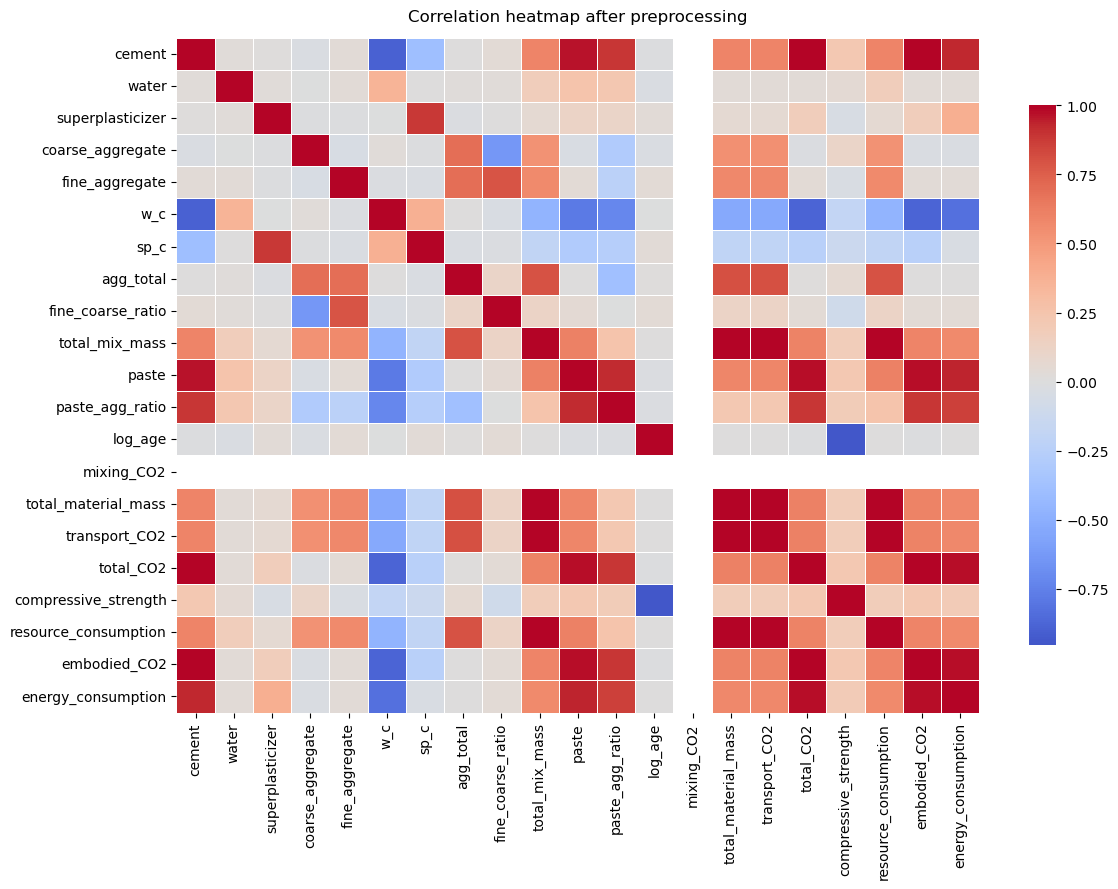

In [57]:
heatmap_df = pd.concat(
    [X_prepared_df, y], axis=1
)

corr = heatmap_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation heatmap after preprocessing", pad=12)
plt.tight_layout()
plt.show()

# save data

In [58]:
os.makedirs("../data", exist_ok=True)

prepared_data = pd.concat([X_prepared_df, y], axis=1)

prepared_data.to_csv("../data/preprocessed_dataset.csv", index=False)